# GPU Training with Sinkhorn

How to speed up GGML training by using the Sinkhorn OT solver on a GPU.

In [1]:
import ggml_ot
import scanpy as sc
import pandas as pd

By default, GGML uses the exact Earth Mover's Distance (EMD). EMD calls a network-simplex LP solver per distribution pair which is only supported on CPU. The Sinkhorn solver instead expresses OT as a sequence of batched matrix operations that vectorize across all pairs in a triplet batch, which maps cleanly onto a GPU.

We reuse the Breast cancer dataset from *Kumar et al., 2023* (714,331 cells from 126 donors) from the [fast approximation tutorial](../tutorials/5_fast_approximations.html).

In [ ]:
id = "b8b5be07-061b-4390-af0a-f9ced877a068.h5ad"
adata = ggml_ot.data.load_cellxgene(id)
sc.pp.highly_variable_genes(adata, n_top_genes=5000, subset=True)

## Setup dataset with `normalize()`

Sinkhorn uses entropic regularization which is controlled by the `entropic_reg` parameter which is sensitive to the scale of the data. To better compare and tune `entropic_reg` across datasets, we normalize datasets by calling `dataset.normalize()`.

In [ ]:
dataset = ggml_ot.from_anndata(
    adata, patient_col="donor_id", label_col="reported_diseases"
)
dataset.normalize()

In [ ]:
train_params = {"n_splits": 2}
scores = {}

## Sinkhorn on GPU

Passing `entropic_reg > 0` to `train()` dispatches the inner OT solve to Sinkhorn. With `settings.device="cuda"` the GGML optimization, including the inner OT, is performed on the GPU as batched vectorized operations which leads to a significant speed-up.

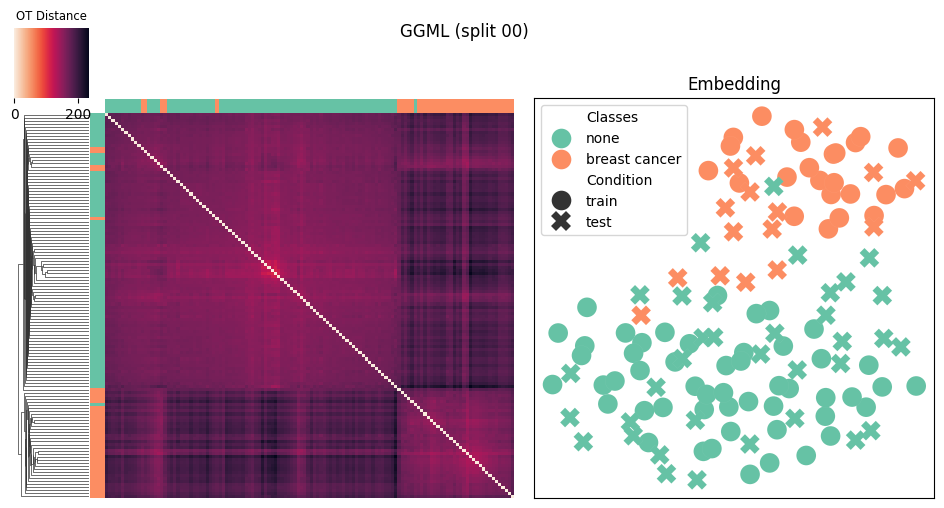

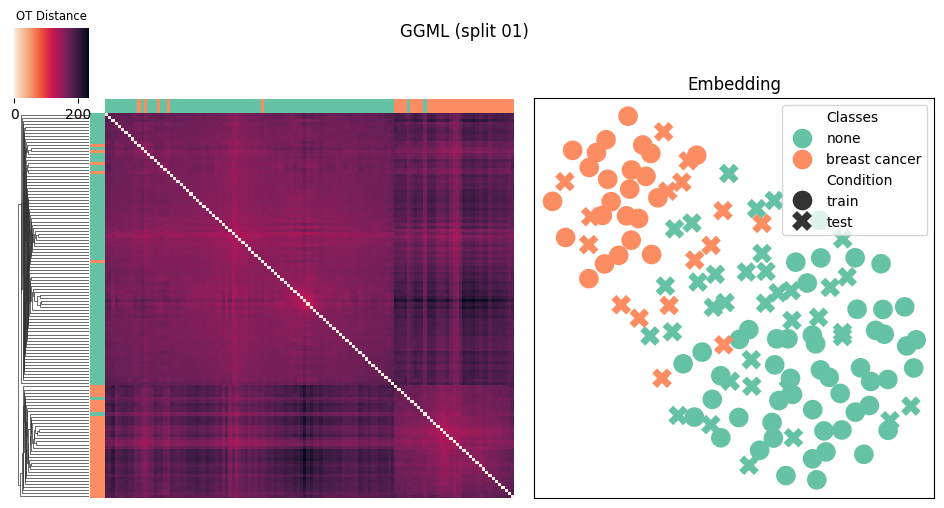

In [4]:
ggml_ot.settings.device = "cuda"

_, scores["sinkhorn (GPU)"] = dataset.train_test(
    **train_params, entropic_reg=5.0
)

## Sinkhorn on CPU

Even on CPU (`settings.device="cpu"`) the computation time benefits from batched tensor operations and better utilization of large number of CPU threads (`settings.n_threads`) compared to the slow training using EMD2 (`entropic_reg=0`). 

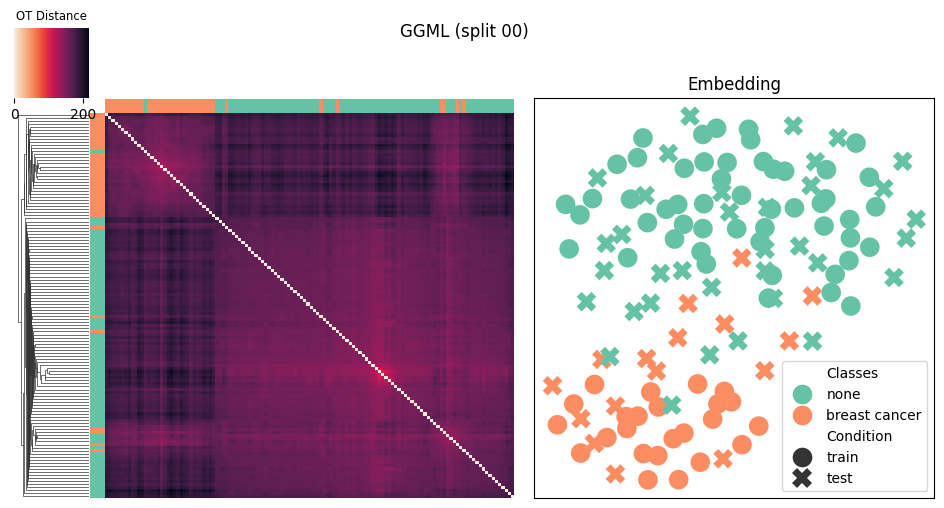

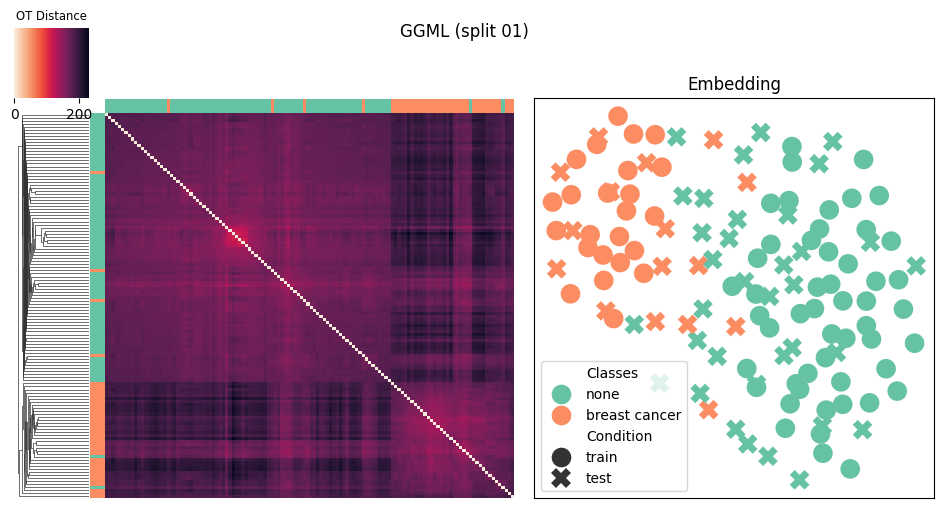

In [5]:
ggml_ot.settings.device = "cpu"
ggml_ot.settings.n_threads = 64

_, scores["sinkhorn (CPU)"] = dataset.train_test(
    **train_params, entropic_reg=5.0
)

## Exact EMD2 on GPU and CPU

For contrast, we run the exact EMD2 solver (`entropic_reg=0.0`, the default) on both devices. EMD2 is computed by the network-simplex LP solver shipped with POT, which is **not batched** and runs **on the CPU**. Setting `settings.device="cuda"` therefore only moves tensors to the GPU for the triplet loss, the OT solves themselves stay on the CPU and `train()` emits a warning to make this visible.

/home/kuehn/ot_metric_learning/gaussian-ground-metric-learning/code/ggml-ot_privat/ggml_ot/optimization/api.py:44: UserWarning: Exact EMD2 solver is CPU-bound; no GPU acceleration is used for OT solves.
  warnings.warn(


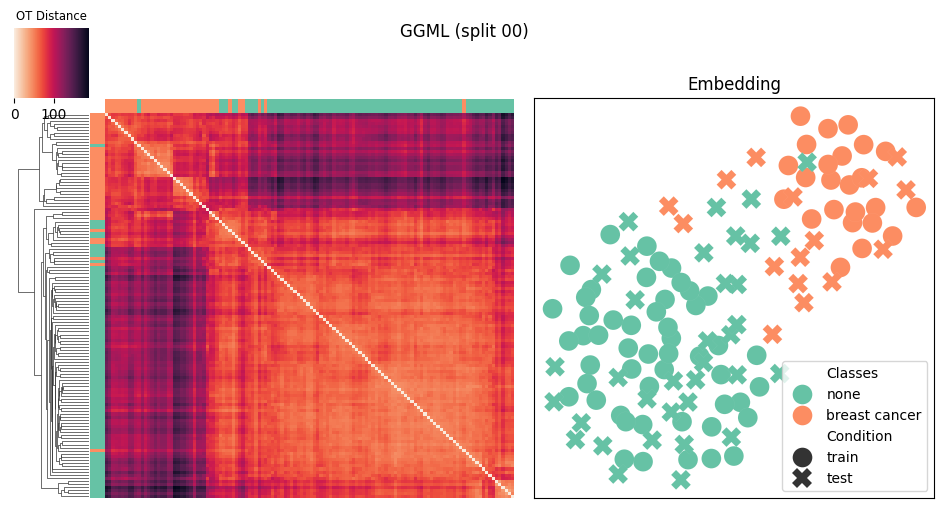

/home/kuehn/ot_metric_learning/gaussian-ground-metric-learning/code/ggml-ot_privat/ggml_ot/optimization/api.py:44: UserWarning: Exact EMD2 solver is CPU-bound; no GPU acceleration is used for OT solves.
  warnings.warn(


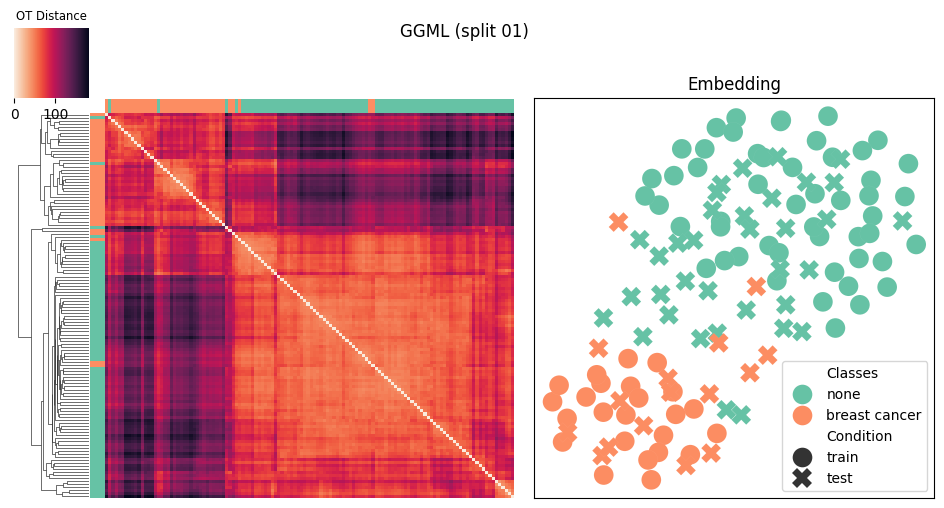

In [6]:
ggml_ot.settings.device = "cuda"

_, scores["emd2 (GPU)"] = dataset.train_test(**train_params)

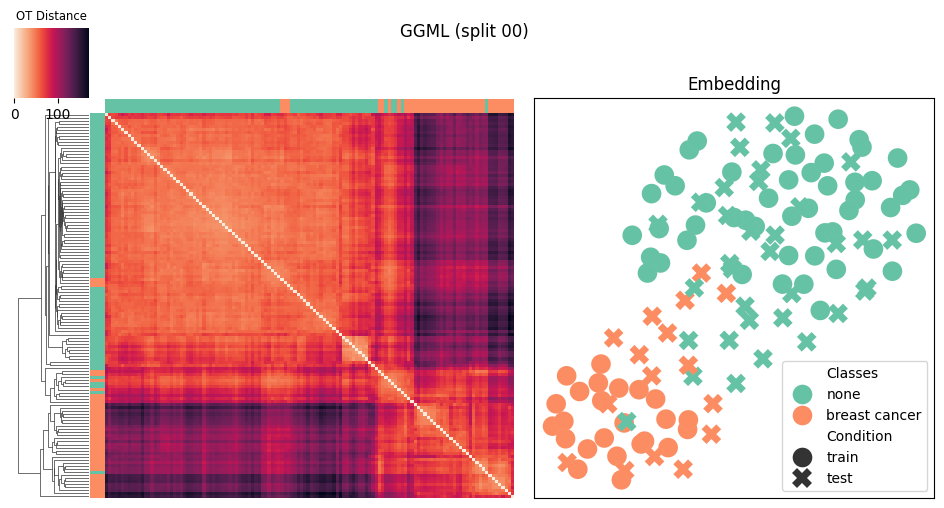

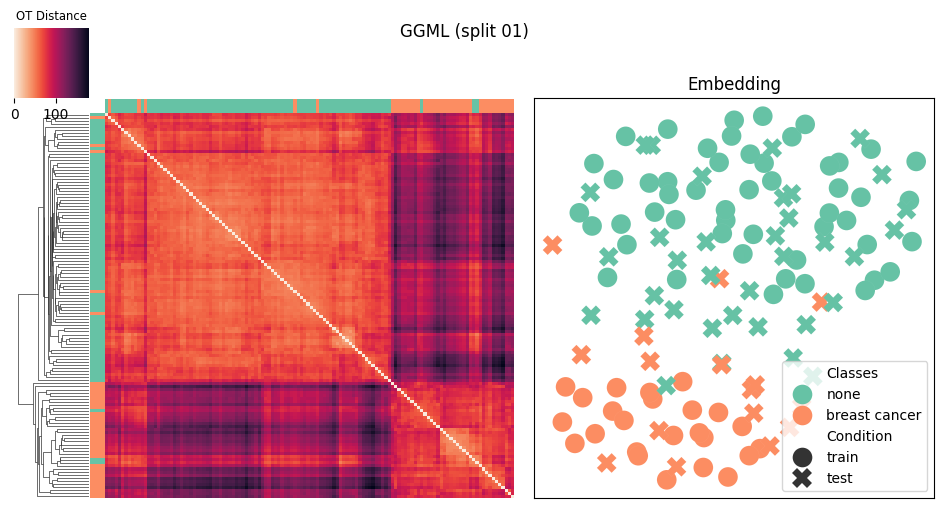

In [7]:
ggml_ot.settings.device = "cpu"

_, scores["emd2 (CPU)"] = dataset.train_test(**train_params)

As expected, the non-batched EMD2 cannot leverage GPU speed-up and massive parallelization.

## Performance and classification comparison

`train_test()` reports the mean epoch time alongside the usual classification and clustering metrics. Sorting by epoch time lines up the four setups from fastest to slowest.

In [8]:
scores_df = pd.concat(
    [scores[setup] for setup in scores], ignore_index=True
).set_index(
    pd.Index(scores.keys(), name="setup")
).sort_values(("epoch_time(s)", "Mean"))

ggml_ot.pl.table(
    scores_df,
    style_performance=True,
    title="Sinkhorn vs. EMD2 on GPU and CPU",
)

**Takeaways**:
- To leverage GPU speed-up the Sinkhorn solver must be used with `entropic_reg > 0`
    - `normalize()` before tuning `entropic_reg` as it makes regularization strengths transferable across datasets
- EMD2 solver is not batched and computations are CPU-bound regardless of `settings.device`

See the [fast approximations tutorial](../tutorials/5_fast_approximations.html) for other computational speed-ups for both, EMD2 and Sinkhorn.